***ETL + análise prática:***

 **Extração:** carregar CSV.

 **Transformação:**

> Garantir números (renda_mensal, dividas_total).

>  Criar nova coluna: relação dívida/renda.

 **Carga:** salvar dados tratados para análise de risco.

In [269]:
import pandas as pd

df = pd.read_csv("banco_box_sintetico.csv")
print(df.shape)
df.head()

(1000, 13)


,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,possui_imovel,possui_veiculo,cargo_atual,risco_credito
0,50,4145.83,1.4,5798,13957.29,1,1,1,0,Não,Não,Analista de TI,Médio
1,40,14080.13,0.9,39607,57549.72,1,0,2,0,Não,Não,Enfermeiro,Alto
2,59,7550.31,21.0,7865,20694.49,3,4,0,0,Não,Sim,Advogado,Médio
3,27,2390.01,5.6,1340,10593.18,17,5,3,0,Sim,Não,Analista de TI,Baixo
4,39,17135.27,20.3,45245,77949.94,1,3,2,0,Sim,Não,Contador,Alto


In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idade                1000 non-null   int64  
 1   renda_mensal         951 non-null    float64
 2   tempo_emprego        1000 non-null   float64
 3   dividas_total        1000 non-null   int64  
 4   limite_cartao        1000 non-null   float64
 5   historico_credito    1000 non-null   int64  
 6   num_cartoes_credito  1000 non-null   int64  
 7   num_emprestimos      1000 non-null   int64  
 8   atraso_pagamento     1000 non-null   int64  
 9   possui_imovel        1000 non-null   object 
 10  possui_veiculo       1000 non-null   object 
 11  cargo_atual          1000 non-null   object 
 12  risco_credito        1000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 101.7+ KB


In [271]:
df["renda_mensal"] = pd.to_numeric(df["renda_mensal"], errors="coerce")
df["dividas_total"] = pd.to_numeric(df["dividas_total"], errors="coerce")
df["renda_mensal"] = df["renda_mensal"].fillna(df["renda_mensal"].mean())
df["dividas_total"] = df["dividas_total"].fillna(df["dividas_total"].mean())

In [272]:
df["relacao_divida_renda"] = df["dividas_total"] / df["renda_mensal"]

In [273]:
print(df.shape)
df.dtypes

(1000, 14)


,0
idade,int64
renda_mensal,float64
tempo_emprego,float64
dividas_total,int64
limite_cartao,float64
historico_credito,int64
num_cartoes_credito,int64
num_emprestimos,int64
atraso_pagamento,int64
possui_imovel,object


In [274]:
df.to_csv("banco_box_tratados.csv", index=False)

***O QUE FOI FEITO:***

✅**Upload** do csv dentro dos arquivos do notebook;

✅**Importado** panda;

✅**Print** do shape - linhas por coluna;

✅**Visualização** das 5 primeiras linhas;

✅Trouxe as **informações** sobre os tipos de dados de cada coluna para possivel correção durante a análise;

✅**Tratamento** de dados, transformando as colunas renda_mensal e dividas_total em tipo numérico, garantindo que valores diferentes de int e float, sejam imediatamente corrigidos para NaN, evitando o erro;

    ⚓ Em seguida, garantiu-se que os possíveis valores faltantes fossem substituidos pela média da própria coluna;

✅**Criação** da coluna 'relacao_divida_renda' fazendo uma divisão linha por linha entre as colunas dividas_total e renda_mensal. Essa coluna foi criada para apontar o nível de endividamento da pessoa;

▶ Logo mais, apenas para fins de **confirmação**, chamamos novamente o shape e o df.types para confirmar cada coluna com seus respectivo tipo de dado;

✅Depois de tratados os dados, foi **salvo** o DataFrame em um arquivo CSV, identificando-o do não tratado e pronto para uso;

**================================================================================================================================**

***MATPLOTLIB***

 **Gerar** gráficos de Barras;

 **NumPy:**
    o média do histórico de crédito.

 **Classificação:** prever se o cliente possui risco alto, médio ou baixo.

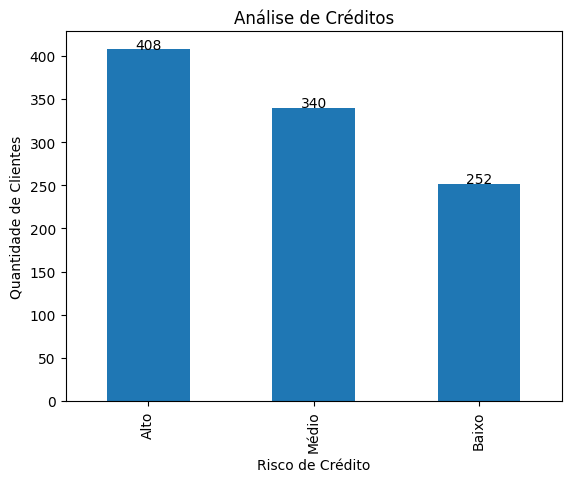

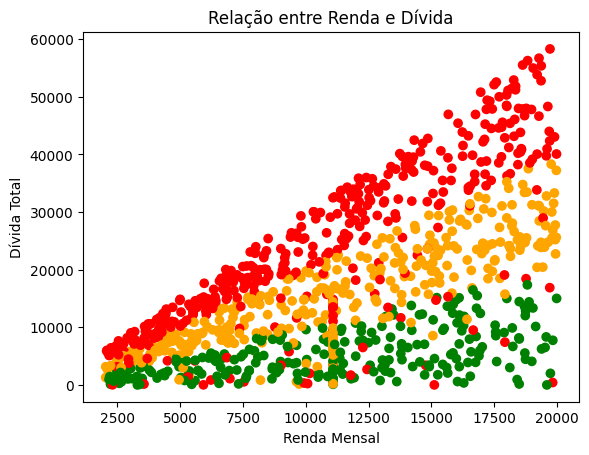

In [275]:
import matplotlib.pyplot as plt

cores = {"Baixo": "green", "Médio": "orange", "Alto": "red"}

contagem = df["risco_credito"].value_counts()
ax = contagem.plot(kind="bar")

plt.title("Análise de Créditos")
plt.xlabel("Risco de Crédito")
plt.ylabel("Quantidade de Clientes")

for i, valor in enumerate(contagem):
    plt.text(i, valor + 0.5, str(valor), ha='center')


plt.figure()

plt.scatter(df["renda_mensal"], df["dividas_total"], c=df["risco_credito"].map(cores))

plt.title("Relação entre Renda e Dívida")
plt.xlabel("Renda Mensal")
plt.ylabel("Dívida Total")

plt.show()


In [276]:
import numpy as np

media = np.mean(df["historico_credito"])

print("Média do histórico de crédito:", media)

Média do histórico de crédito: 9.95


***INTERPRETAÇÃO DE DADOS***

**PRIMEIRO GRÁFICO**

Clientes = 1000;

A maior parte dos clientes está em alto risco. São clientes que se endividam mais do que sua renda pode suportar;

O grupo de baixo risco é o menor = menos clientes “seguros”.

A instituição tem uma concentração preocupante de clientes com maior probabilidade de inadimplência.

**SEGUNDO GRÁFICO**

Podemos analisar que clientes que possuem renda mais elevada consegue suportar um endividamento maior;

Não é possível identificar o perfil de investidor com base neste gráfico:

    Embora clientes com baixa relação dívida/renda possam indicar um comportamento financeiro mais cauteloso, não é possível afirmar, com base nesses dados, que se tratam de investidores conservadores, pois o gráfico não apresenta informações sobre o perfil de investimento dos clientes.

*Esclarecimento:*
O gráfico considera mais variáveis - número de atrasos, número de dependentes, por exemplo - para além da RENDA x ENDIVIDAMENTO; Por isso, clientes de **alto risco** em situação de **alta renda** e **baixo endividamento**, pode indicar histórico de crédito ruim (podem ter score baixo por exemplo), ou comportamento suspeito (limite alto disponível sendo usado de forma irregular) e etc.

**MÉDIA DO HISTÓRICO DE CRÉDITO: 9.95**

Os clientes possuem, em média, aproximadamente 10 anos de histórico de crédito, o que indica uma base de dados relativamente madura e permite uma avaliação mais confiável do risco.



***O CÓDIGO:***

✔ Mostra a quantidade exata de clientes em cima das barras;
✔ Conta quantos clientes estão em cada nível de risco;

🟢 clientes saudáveis

🟠 intermediários

🔴 clientes perigosos

✔ Cria um gráfico de barras;
✔ Cria um gráfico de dispersão;

✔ Adiciona título e nomes nos eixos;

✔ Mostra o gráfico;
✔ Mostra a média do histórico de crédito;

**================================================================================================================================**

**MACHINE LEARNING**

In [277]:
df.describe()

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,relacao_divida_renda
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54.714000,11084.092324,15.074200,16509.753000,31552.676700,9.950000,2.486000,1.479000,5.921000,1.496648
std,20.721138,5115.771360,8.606815,13004.206382,20229.370451,6.129525,1.690758,1.123753,14.363114,0.864642
min,19.000000,2039.990000,0.100000,0.000000,2374.180000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,6772.857500,7.500000,6141.250000,15897.767500,5.000000,1.000000,0.000000,0.000000,0.748531
50%,55.000000,11084.092324,14.900000,13289.000000,26743.405000,10.000000,2.000000,1.000000,0.000000,1.488290
75%,73.000000,15458.865000,22.700000,24176.250000,43493.482500,15.000000,4.000000,2.000000,0.000000,2.219970
max,90.000000,19977.490000,30.000000,58298.000000,97632.300000,20.000000,5.000000,3.000000,60.000000,2.997258


In [278]:
df.isna().sum()

,0
idade,0
renda_mensal,0
tempo_emprego,0
dividas_total,0
limite_cartao,0
historico_credito,0
num_cartoes_credito,0
num_emprestimos,0
atraso_pagamento,0
possui_imovel,0


NORMALIZAÇÃO DOS DADOS --------------------------------------------------------------------------------------------------

In [279]:
from sklearn.preprocessing import MinMaxScaler

In [280]:
normalizador = MinMaxScaler(feature_range=(0, 1))

**Min-Max Scaling:** transforma os valores para o intervalo entre 0 e 1, preservando a distribuição original

In [281]:
colunas = df.columns

In [282]:
col_normalizacao = [
    'renda_mensal',
    'dividas_total',
    'relacao_divida_renda',
    'historico_credito'
]

In [283]:
for col in col_normalizacao:
  df[col] = normalizador.fit_transform(df[col].values.reshape(-1, 1))

In [284]:
df.head()

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,possui_imovel,possui_veiculo,cargo_atual,risco_credito,relacao_divida_renda
0,50,0.117399,1.4,0.099455,13957.29,0.05,1,1,0,Não,Não,Analista de TI,Médio,0.466598
1,40,0.671227,0.9,0.679389,57549.72,0.05,0,2,0,Não,Não,Enfermeiro,Alto,0.938515
2,59,0.307196,21.0,0.134910,20694.49,0.15,4,0,0,Não,Sim,Advogado,Médio,0.347544
3,27,0.019513,5.6,0.022985,10593.18,0.85,5,3,0,Sim,Não,Analista de TI,Baixo,0.187060
4,39,0.841549,20.3,0.776099,77949.94,0.05,3,2,0,Sim,Não,Contador,Alto,0.880959


  Pelo fato das variáveis possuirem escalas muitos diferentes, o modelo pode considerar que valores maiores são mais importantes. Então a normalização transforma todos na mesma escala, tendo então as variáveis em peso equilibrado. Isso melhora o modelo fazendo com que ele evite distorções e fique mais justo.


**Esclarecimento**

    Embora o modelo Random Forest não exija normalização, essa etapa foi aplicada para garantir maior consistência nos dados.

Separação em Treino e Teste --------------------------------------------------------------------------------------------------

In [285]:
from sklearn.model_selection import train_test_split

In [286]:
X = df[[
    'renda_mensal',
    'dividas_total',
    'relacao_divida_renda',
    'historico_credito',
    'num_emprestimos',
    'atraso_pagamento'
]].values  # Features de Seleção

Y = df['risco_credito'].values                     # Feature Alvo

In [287]:
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size=0.30, random_state=42)

Nesta parte, houve uma definição de variáveis em

> X(features) - dados usados para aprender e;

> Y(target) - resposta do que risco que se quer prever

Então há uma divisão dos dados, em uma parte para ensinar o modelo e a outra para avaliar o modelo, considerando um parametro de 30% dos dados para teste (test_size=0.30)

X_treino → dados de entrada pra treinar;

X_teste → dados de entrada pra testar;

Y_treino → respostas do treino;

Y_teste → respostas reais pra comparar;

Criação do Modelo --------------------------------------------------------------------------------------------------

In [288]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_treino, Y_treino)

RandomForestClassifier(random_state=42)

In [289]:
Y_pred = modelo.predict(X_teste)

Foi se escolhido o modelo Random Forest, nele nós treinamos a análise de dados conforme as variáveis estabelecidas e solicitamos a sua previsão.

Avaliação do Modelo --------------------------------------------------------------------------------------------------

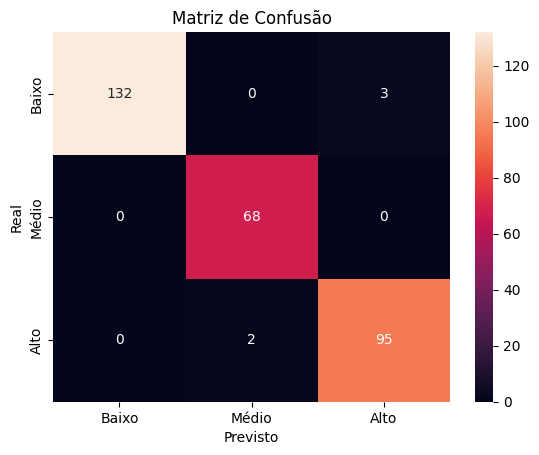

In [290]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Baixo", "Médio", "Alto"]
matriz = confusion_matrix(Y_teste, Y_pred)
sns.heatmap(matriz, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

**LEITURA DO GRÁFICO**

Esse gráfico mostra como o modelo está acertando e errando.

As linhas representam os valores reais dos clientes e as colunas mostram o que o modelo previu.

Os números na diagonal são os acertos, e como podemos ver, eles são bem altos, indicando que o modelo está funcionando muito bem.

Já os valores fora da diagonal representam erros, que são poucos, mostrando que o modelo tem alta precisão na classificação dos riscos.

In [291]:

modelo.score(X_treino, Y_treino)

1.0

In [292]:

modelo.score(X_teste, Y_teste)

0.9833333333333333

In [293]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(Y_teste, Y_pred)

print("Acurácia:", acuracia)

Acurácia: 0.9833333333333333


**ACURACIA**
98%

In [294]:
from sklearn.metrics import classification_report

print(classification_report(Y_teste, Y_pred))

              precision    recall  f1-score   support

        Alto       1.00      0.98      0.99       135
       Baixo       0.97      1.00      0.99        68
       Médio       0.97      0.98      0.97        97

    accuracy                           0.98       300
   macro avg       0.98      0.99      0.98       300
weighted avg       0.98      0.98      0.98       300



PRECISION: quando ele acerta, ele acerta bem

RECALL: ele consegue encontrar todos os casos

F1-SCORE: equilíbrio entre os dois

SUPPORT: quantidade de exemplos


ACCURACY: acurácia de 98%

MACRO AVG: média simples entre as classes

WEIGHTED AVG: média considerando quantidade de dados